In [13]:
%pip install seaborn


[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import seaborn as sns

print("Seaborn is ready")

Seaborn is ready


In [15]:
# =========================
# Import libraries
# =========================

import ast                                   # Convert string lists into Python lists
import pandas as pd                          # Data analysis
from datasets import load_dataset            # Load dataset
import matplotlib.pyplot as plt              # Base plotting
import seaborn as sns                        # Better statistical visualizations

In [16]:
# =========================
# Load dataset
# =========================

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [17]:
# =========================
# Clean dataset
# =========================

# Convert dates into datetime objects
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert skill strings into Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [18]:
# =========================
# Keep only U.S. Data Scientist jobs
# =========================

df_DS_US = df[
    (df["job_title_short"] == "Data Scientist") &
    (df["job_country"] == "United States")
].copy()

# Remove rows that don't have yearly salary information
df_DS_US = df_DS_US.dropna(subset=["salary_year_avg"])

# Quick sanity check
print(df_DS_US.shape)

# Preview the data
df_DS_US.head()

(4553, 17)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
257,Data Scientist,Senior Bioinformatics Research Scientist- Data...,"Brighton, TN",via Work RN,Full-time,False,Georgia,2023-11-20 13:40:09,False,False,United States,year,103128.0,NaN,St. Jude Children's Research Hospital,"[r, electron]","{'libraries': ['electron'], 'programming': ['r']}"
450,Data Scientist,Data Defense Developer - USDS,"Mountain View, CA",via LinkedIn,Full-time,False,"New York, United States",2023-12-02 13:19:59,False,True,United States,year,157500.0,NaN,TikTok,"[go, python, java, mongo, redis, aws, pandas, ...","{'cloud': ['aws'], 'databases': ['redis'], 'li..."
1257,Data Scientist,Data Scientist,"Minneapolis, MN",via Adzuna,Full-time,False,"Illinois, United States",2023-02-21 13:25:40,False,True,United States,year,70700.0,NaN,Target,"[java, scala, python, r, kotlin, sql, spark]","{'libraries': ['spark'], 'programming': ['java..."


In [19]:
# =========================
# One skill per row
# =========================

# Example:
# ['python', 'sql', 'aws']
# becomes three separate rows
df_DS_US_exploded = df_DS_US.explode("job_skills")

In [20]:
# =========================
# Explode skills + group statistics
# =========================

# Split each job's skill list into separate rows
df_DS_US_exploded = df_DS_US.explode("job_skills")

# Group by skill and calculate:
# count  = how many Data Scientist postings mention the skill
# median = median yearly salary for postings mentioning the skill
df_DS_group = (
    df_DS_US_exploded
    .groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
)

# Preview the grouped results
df_DS_group.head()

,count,median
job_skills,,
airflow,94,157000.0
airtable,6,224250.0
alteryx,53,122500.0
angular,7,115000.0
ansible,3,115000.0


In [21]:
# =========================
# Highest-paying skills
# =========================

df_DS_top_pay = (
    df_DS_group
    .sort_values(
        by="median",
        ascending=False          # Highest salary first
    )
    .head(10)                    # Keep top 10
)

df_DS_top_pay

,count,median
job_skills,,
asana,5,259000.00000
airtable,6,224250.00000
watson,10,213500.00000
unreal,4,211500.00000
ruby on rails,4,195500.00000
redhat,1,189500.00000
notion,9,187500.00000
slack,11,180000.00000
hugging face,15,179000.00000


In [22]:
# =========================
# Most in-demand skills
# =========================

df_DS_top_demand = (
    df_DS_group
    .sort_values(
        by="count",
        ascending=False          # Most frequently requested first
    )
    .head(10)                    # Keep top 10 most common skills
    .sort_values(
        by="median",
        ascending=False          # Order those 10 by salary for plotting
    )
)

df_DS_top_demand

,count,median
job_skills,,
tensorflow,474,149646.0
spark,718,135959.5
sql,2463,134500.0
aws,768,134000.0
python,3358,131867.0
r,2053,126000.0
tableau,989,125000.0
hadoop,468,125000.0
excel,490,124290.0


In [23]:
# =========================
# Set Seaborn style
# =========================

sns.set_theme(
    style="whitegrid",          # Add subtle gridlines
    palette="viridis"           # Use the viridis color palette
)

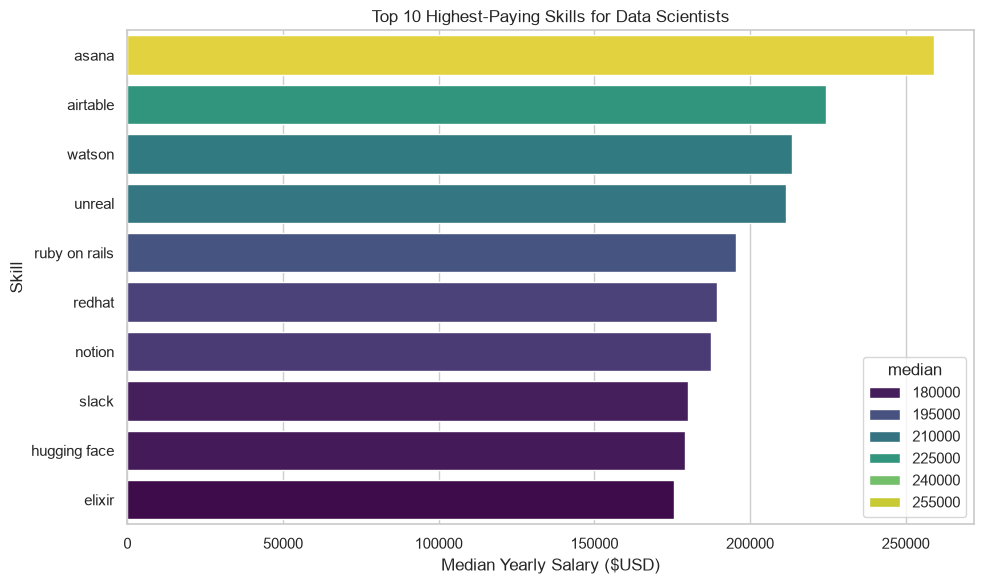

In [27]:
# =========================
# Highest-paying Data Scientist skills
# =========================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_DS_top_pay.reset_index(),
    x="median",                 # Bar length = median salary
    y="job_skills",             # One horizontal bar per skill
    hue="median",               # Color intensity also represents salary
    palette="viridis",          # Continuous palette: low -> high
    legend=True                 # Show the salary color scale
)

plt.title("Top 10 Highest-Paying Skills for Data Scientists")
plt.xlabel("Median Yearly Salary ($USD)")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

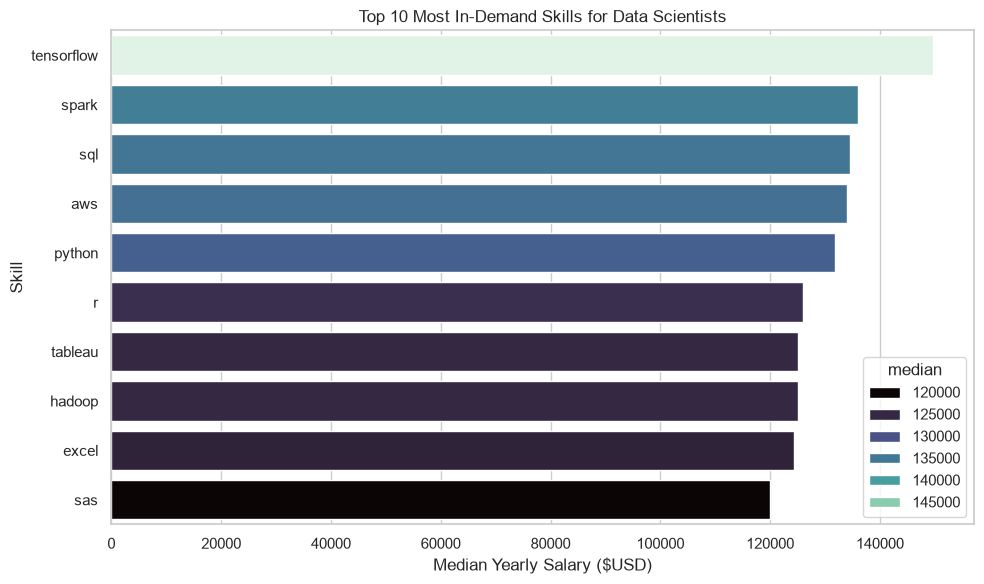

In [28]:
# =========================
# Most in-demand Data Scientist skills
# =========================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_DS_top_demand.reset_index(),
    x="median",                 # Median salary for each popular skill
    y="job_skills",             # One horizontal bar per skill
    hue="median",               # Color reflects salary level
    palette="mako",             # Different Seaborn palette for variety
    legend=True
)

plt.title("Top 10 Most In-Demand Skills for Data Scientists")
plt.xlabel("Median Yearly Salary ($USD)")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

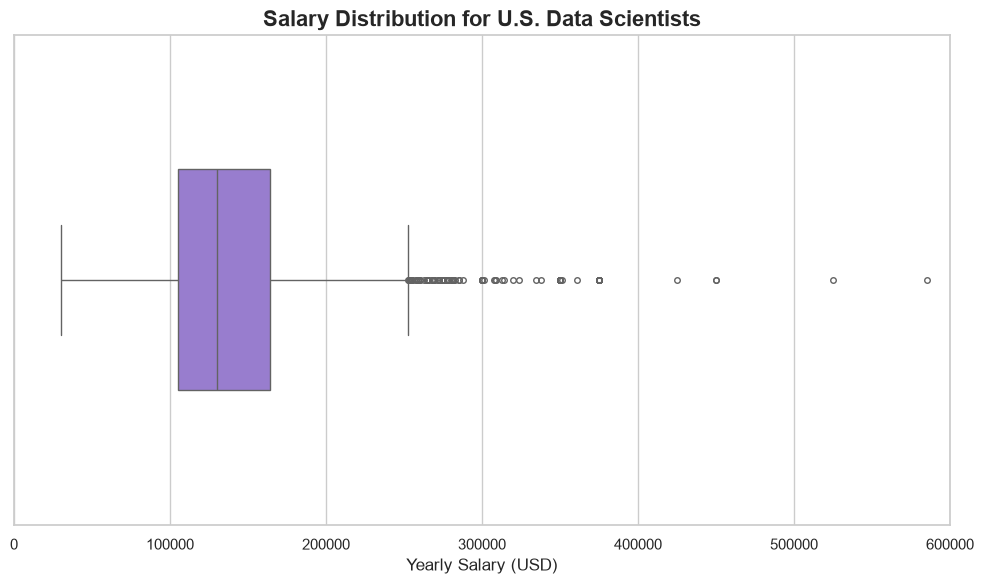

In [29]:
# =====================================
# Seaborn Boxplot - Data Scientist Salaries
# =====================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_DS_US,
    x="salary_year_avg",
    color="mediumpurple",     # Main box color
    width=0.45,
    fliersize=4               # Size of outlier dots
)

plt.title(
    "Salary Distribution for U.S. Data Scientists",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Yearly Salary (USD)")
plt.ylabel("")

plt.xlim(0, 600000)

plt.tight_layout()
plt.show()

/var/folders/g8/653mbdtn65n85h__s3gx0z3r0000gn/T/ipykernel_7400/4178734388.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


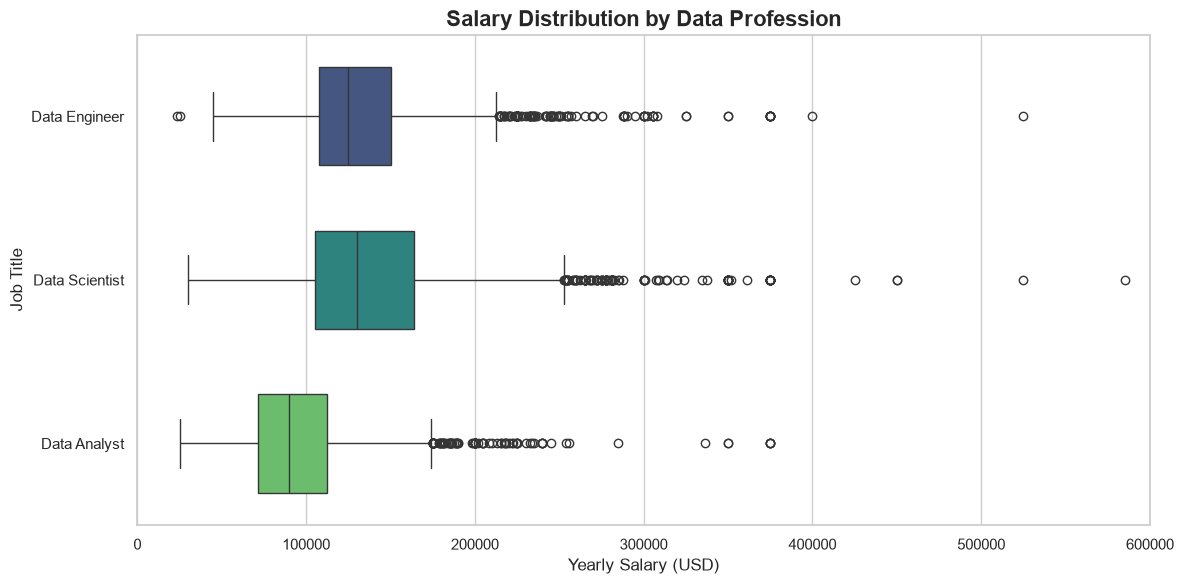

In [30]:
# =====================================
# Compare salaries across job titles
# =====================================

job_titles = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer"
]

df_compare = df[
    (df["job_title_short"].isin(job_titles)) &
    (df["job_country"] == "United States")
].copy()

df_compare = df_compare.dropna(subset=["salary_year_avg"])

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_compare,
    x="salary_year_avg",
    y="job_title_short",
    palette="viridis",          # Nice gradient colors
    width=0.6,
    showfliers=True
)

plt.title(
    "Salary Distribution by Data Profession",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Yearly Salary (USD)")
plt.ylabel("Job Title")

plt.xlim(0,600000)

plt.tight_layout()
plt.show()

## 📊 Key Takeaways

### What this chart shows
This boxplot compares the salary distributions of three common data careers in the United States:

- Data Analyst
- Data Scientist
- Data Engineer

Each box summarizes thousands of job postings rather than individual salaries.

### How to read a boxplot

- **Orange line** → Median salary (middle value)
- **Box** → Middle 50% of salaries (Interquartile Range)
- **Whiskers** → Typical salary range
- **Dots** → Outliers (very high-paying positions)

### Insights

- **Data Scientists** generally have the highest median salary.
- **Data Engineers** have a similar salary range but slightly more consistency.
- **Data Analysts** have the lowest median salary of the three roles.
- All three careers contain high-paying outliers above \$300K, although these positions are relatively uncommon.

### Why this matters

A boxplot allows us to compare not only average salaries, but also salary spread, consistency, and unusually high-paying jobs.

/var/folders/g8/653mbdtn65n85h__s3gx0z3r0000gn/T/ipykernel_7400/278896696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


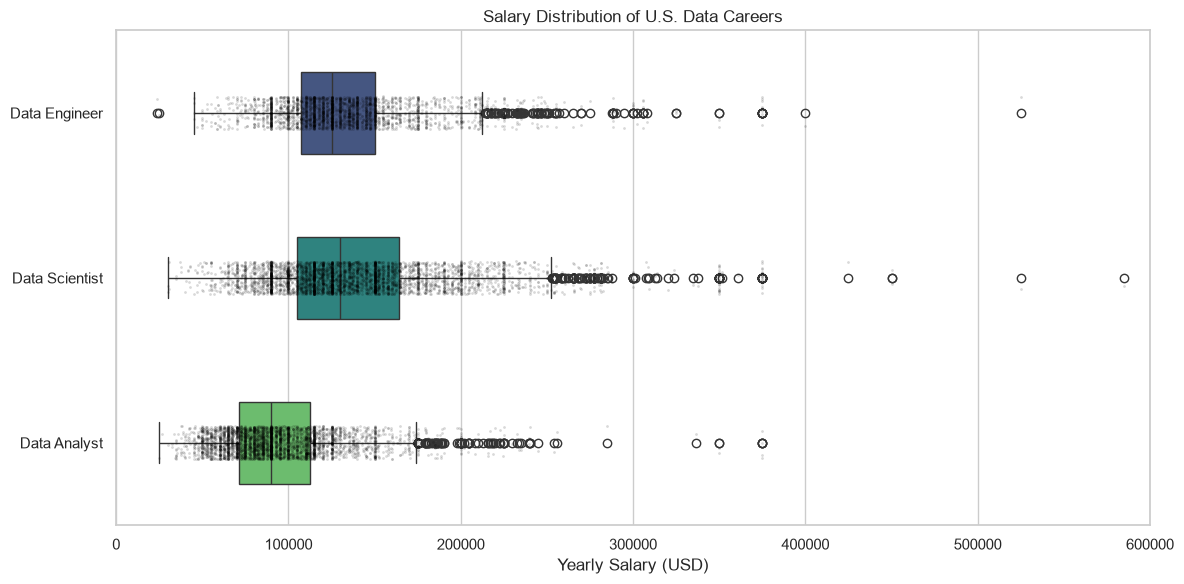

In [32]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_compare,
    x="salary_year_avg",
    y="job_title_short",
    palette="viridis",
    width=0.5
)

sns.stripplot(
    data=df_compare,
    x="salary_year_avg",
    y="job_title_short",
    color="black",
    alpha=0.15,
    size=2
)

plt.title("Salary Distribution of U.S. Data Careers")
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("")

plt.xlim(0,600000)

plt.tight_layout()
plt.show()

## 📊 Key Takeaways

### What this chart adds

This visualization combines a **boxplot** with a **stripplot**.

The boxplot summarizes the salary distribution, while the stripplot overlays the actual job postings.

### What we learn

- Every black dot represents one job posting.
- Most salaries cluster within the box and whiskers.
- A small number of postings earn significantly more than the rest, creating the visible outliers.
- Data Scientists and Data Engineers both show wider salary ranges than Data Analysts.

### Why use Seaborn?

Seaborn makes statistical visualizations easier to build by providing:

- Better default styling
- Attractive color palettes
- Easy overlay of multiple plot types
- Cleaner statistical visualizations than basic Matplotlib

### Portfolio takeaway

Instead of looking only at average salary, this visualization helps identify:
- salary consistency,
- variability,
- and the frequency of exceptionally high-paying positions.